In [1]:
import pandas as pd

df = pd.read_csv("ECG_heartbeat.csv")

print(df.head())
print(df.info())
print(df.describe())

   1.000000000000000000e+00  7.582644820213317871e-01  \
0                  0.908425                  0.783883   
1                  0.730088                  0.212389   
2                  1.000000                  0.910417   
3                  0.570470                  0.399329   
4                  1.000000                  0.923664   

   1.115702465176582336e-01  0.000000000000000000e+00  \
0                  0.531136                  0.362637   
1                  0.000000                  0.119469   
2                  0.681250                  0.472917   
3                  0.238255                  0.147651   
4                  0.656489                  0.195929   

   8.057851344347000122e-02  7.851240038871765137e-02  \
0                  0.366300                  0.344322   
1                  0.101770                  0.101770   
2                  0.229167                  0.068750   
3                  0.000000                  0.003356   
4                  0.111959  

In [2]:
df_sample = df.sample(500)   # you can use 500–1000 rows
df_sample.to_csv("sample_ecg.csv", index=False)

In [3]:
# Assign proper column names
df.columns = [f'feature_{i}' for i in range(len(df.columns)-1)] + ['label']

# Check again
print(df.head())
print(df['label'].value_counts())

   feature_0  feature_1  feature_2  feature_3  feature_4  feature_5  \
0   0.908425   0.783883   0.531136   0.362637   0.366300   0.344322   
1   0.730088   0.212389   0.000000   0.119469   0.101770   0.101770   
2   1.000000   0.910417   0.681250   0.472917   0.229167   0.068750   
3   0.570470   0.399329   0.238255   0.147651   0.000000   0.003356   
4   1.000000   0.923664   0.656489   0.195929   0.111959   0.175573   

   feature_6  feature_7  feature_8  feature_9  ...  feature_178  feature_179  \
0   0.333333   0.307692   0.296703   0.300366  ...          0.0          0.0   
1   0.110619   0.123894   0.115044   0.132743  ...          0.0          0.0   
2   0.000000   0.004167   0.014583   0.054167  ...          0.0          0.0   
3   0.040268   0.080537   0.070470   0.090604  ...          0.0          0.0   
4   0.122137   0.050891   0.035623   0.055980  ...          0.0          0.0   

   feature_180  feature_181  feature_182  feature_183  feature_184  \
0          0.0        

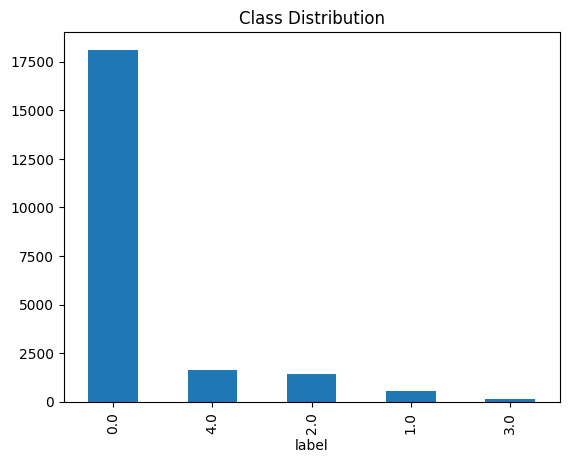

In [4]:
import matplotlib.pyplot as plt

df['label'].value_counts().plot(kind='bar')
plt.title("Class Distribution")
plt.show()

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop('label', axis=1)
y = df['label']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

In [6]:
from imblearn.over_sampling import SMOTE
smote = SMOTE()
X_train, y_train = smote.fit_resample(X_train, y_train)

In [7]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=200, max_depth=10)
rf.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [12]:
y_pred_rf = rf.predict(X_test)

<Axes: >

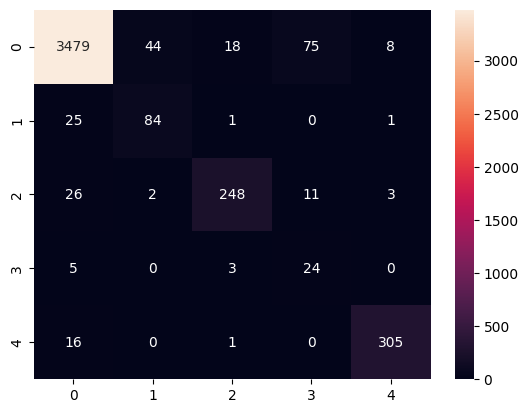

In [13]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, annot=True, fmt='d')

In [15]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

In [18]:
xgb = XGBClassifier(n_estimators=200, learning_rate=0.05, max_depth=6, subsample=0.8, colsample_bytree=0.8)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred))

Accuracy: 0.9559260105046814
              precision    recall  f1-score   support

         0.0       0.98      0.97      0.98      3624
         1.0       0.62      0.74      0.67       111
         2.0       0.88      0.89      0.89       290
         3.0       0.41      0.78      0.54        32
         4.0       0.96      0.98      0.97       322

    accuracy                           0.96      4379
   macro avg       0.77      0.87      0.81      4379
weighted avg       0.96      0.96      0.96      4379



In [19]:
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))

print("\nRF Report:\n", classification_report(y_test, y_pred_rf))
print("\nXGB Report:\n", classification_report(y_test, y_pred_xgb))

Random Forest Accuracy: 0.9454213290705641
XGBoost Accuracy: 0.9559260105046814

RF Report:
               precision    recall  f1-score   support

         0.0       0.98      0.96      0.97      3624
         1.0       0.65      0.76      0.70       111
         2.0       0.92      0.86      0.88       290
         3.0       0.22      0.75      0.34        32
         4.0       0.96      0.95      0.95       322

    accuracy                           0.95      4379
   macro avg       0.74      0.85      0.77      4379
weighted avg       0.96      0.95      0.95      4379


XGB Report:
               precision    recall  f1-score   support

         0.0       0.98      0.97      0.98      3624
         1.0       0.62      0.74      0.67       111
         2.0       0.88      0.89      0.89       290
         3.0       0.41      0.78      0.54        32
         4.0       0.96      0.98      0.97       322

    accuracy                           0.96      4379
   macro avg       0.77 

In [20]:
df.iloc[:, -1].value_counts()

label
0.0    18117
4.0     1608
2.0     1448
1.0      556
3.0      162
Name: count, dtype: int64

In [25]:
from collections import Counter
print("Before SMOTE:", Counter(y_train))

X_train, y_train = smote.fit_resample(X_train, y_train)

print("After SMOTE:", Counter(y_train))

Before SMOTE: Counter({0.0: 14493, 2.0: 14493, 3.0: 14493, 4.0: 14493, 1.0: 14493})
After SMOTE: Counter({0.0: 14493, 2.0: 14493, 3.0: 14493, 4.0: 14493, 1.0: 14493})


In [21]:
xgb = XGBClassifier(scale_pos_weight=3)

In [23]:
from sklearn.metrics import precision_score, recall_score, f1_score
print("F1 Score (XGB):", f1_score(y_test, y_pred_xgb, average='weighted'))

F1 Score (XGB): 0.958160421793078


In [26]:
import pickle
pickle.dump(rf, open("model.pkl", "wb"))
pickle.dump(scaler, open("scaler.pkl", "wb"))